# EDA Analysis-Medical Insurance Premium Detector. With INR (₹)- Indian Rupee.

In [3]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Medicalpremium.csv")

# --- Basic Cleaning ---
print(df.isnull().sum())   # Check for nulls
print(df.dtypes)

Age                        0
Diabetes                   0
BloodPressureProblems      0
AnyTransplants             0
AnyChronicDiseases         0
Height                     0
Weight                     0
KnownAllergies             0
HistoryOfCancerInFamily    0
NumberOfMajorSurgeries     0
PremiumPrice               0
dtype: int64
Age                        int64
Diabetes                   int64
BloodPressureProblems      int64
AnyTransplants             int64
AnyChronicDiseases         int64
Height                     int64
Weight                     int64
KnownAllergies             int64
HistoryOfCancerInFamily    int64
NumberOfMajorSurgeries     int64
PremiumPrice               int64
dtype: object


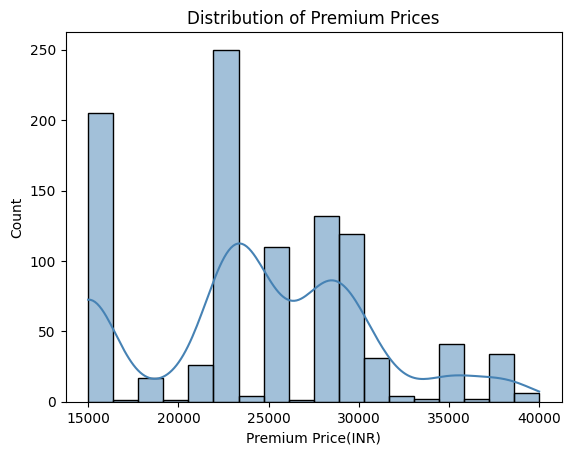

In [ ]:
# Chart 1: PremiumPrice Distribution
plt.figure()
sns.histplot(df["PremiumPrice"], kde=True, color="steelblue")
plt.title("Distribution of Premium Prices")
plt.xlabel("Premium Price(INR)")
plt.savefig("chart1_premium_dist.png")


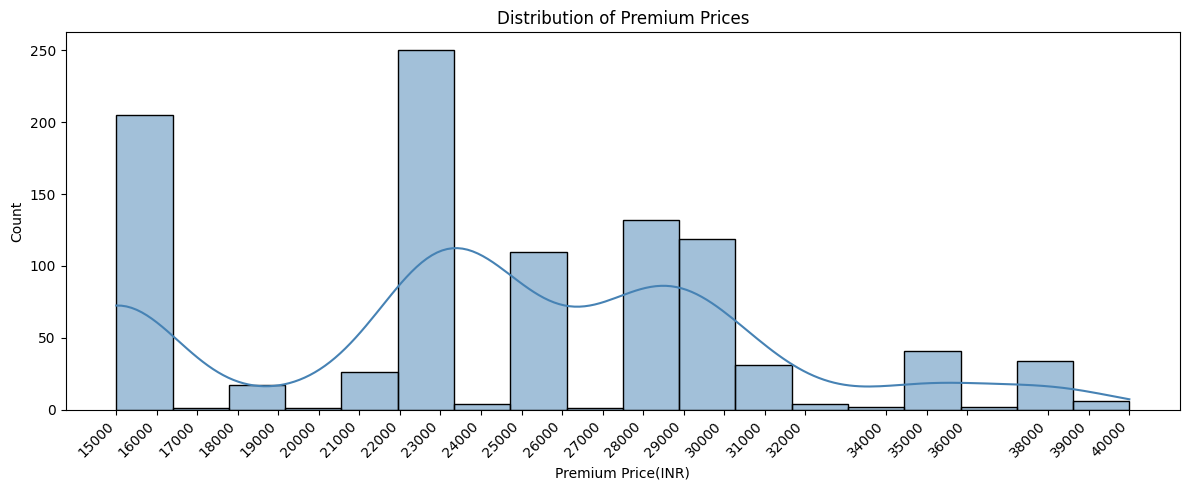

In [31]:
# Chart 1: PremiumPrice Distribution
plt.figure(figsize=(12, 5))  # wider figure to fit all labels
sns.histplot(df["PremiumPrice"], kde=True, color="steelblue")
plt.title("Distribution of Premium Prices")
plt.xlabel("Premium Price(INR)")

# Show every price tier explicitly on x-axis
plt.xticks(
    ticks=sorted(df["PremiumPrice"].unique()),  # use actual values from data
    rotation=45,       # rotate so labels don't overlap
    ha="right"         # align rotated labels to the right
)

plt.tight_layout()    # prevent labels from being cut off
plt.savefig("chart1_premium_dist_explecit.png")

### Insights and Observations:
1. Bimodal distributions- Multiple peaks, premium does not have a smooth spread.
2. The Most Common Premium is ₹23,000.
3. The second-biggest group (200+ people) is at ₹15,000.
4. High premiums are rare (as we can see after ₹30,000 the count drops sharply).

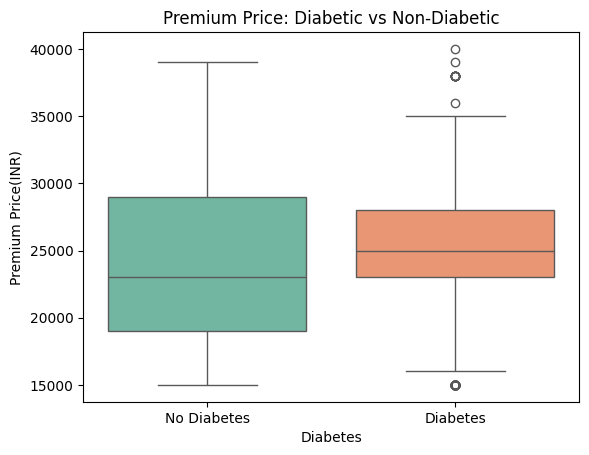

In [28]:
# Chart 2: Diabetes vs PremiumPrice Boxplot
plt.figure()
sns.boxplot(x="Diabetes", y="PremiumPrice", data=df, hue="Diabetes", palette="Set2", legend=False)
plt.title("Premium Price: Diabetic vs Non-Diabetic")
plt.ylabel("Premium Price(INR)")
plt.xticks([0, 1], ["No Diabetes", "Diabetes"])
plt.savefig("chart2_diabetes_boxplot.png")

### Insights and Observation:
1. Diabetics Pay a Higher Median Premium
2. Non-Diabetics Have More Spread-The green box is taller, meaning non-diabetic premiums vary more widely.
3. Diabetics Have Outliers at the Top (likely other conditions with older patients).
4. Both Groups Share the Same Floor. <br>Both groups bottom out around ₹15,000, meaning being non-diabetic doesn't guarantee a low premium— age likely sets the floor.


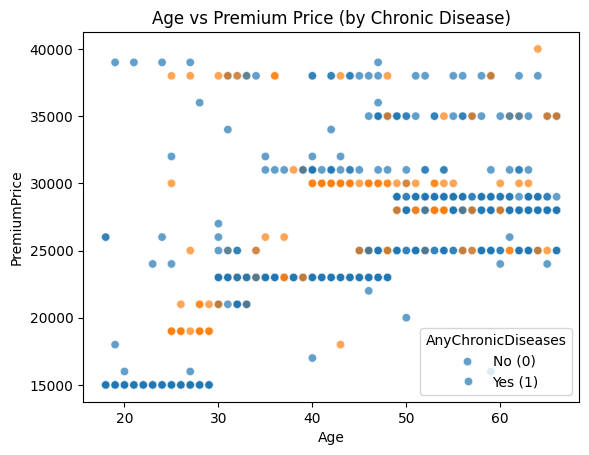

In [20]:
# Chart 3: Age vs PremiumPrice Scatter
plt.figure()
sns.scatterplot(x="Age", y="PremiumPrice", hue="AnyChronicDiseases", data=df, alpha=0.7)
plt.title("Age vs Premium Price (by Chronic Disease)")
plt.legend(title="AnyChronicDiseases", labels=["No (0)", "Yes (1)"])
plt.savefig("chart3_age_premium.png")

### Insights or Observation

### BMI Creation:


In [33]:
df["BMI"] = df["Weight"] / ((df["Height"] / 100) ** 2)
print(df["BMI"].describe())

count    986.000000
mean      27.460709
std        5.878671
min       15.156281
25%       23.393392
50%       27.156602
75%       30.759870
max       50.000000
Name: BMI, dtype: float64


In [34]:
# Create BMI categories
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df["BMI_Category"] = df["BMI"].apply(bmi_category)

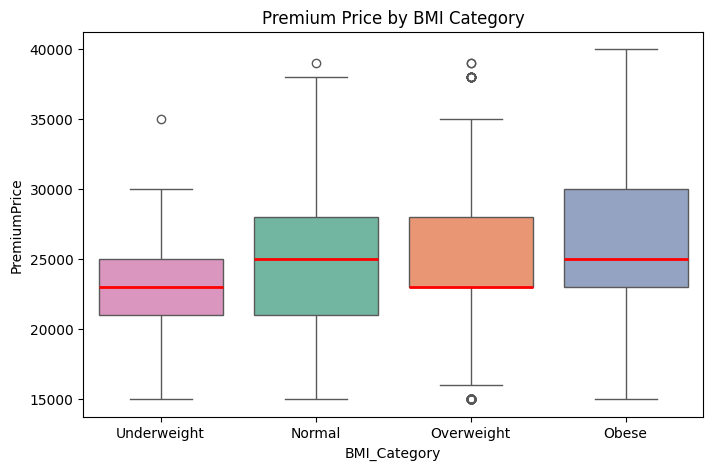

In [42]:
# Boxplot: BMI Category vs Premium Price
plt.figure(figsize=(8, 5))
sns.boxplot(x="BMI_Category", y="PremiumPrice", data=df,
            hue="BMI_Category", palette="Set2", legend=False,
            order=["Underweight", "Normal", "Overweight", "Obese"],
            medianprops={"color": "red", "linewidth": 2}
            )
plt.title("Premium Price by BMI Category")
plt.savefig("chart_bmi_boxplot.png")

In [43]:
# Veryfing weather the median lies on the Q1-25% percentile in the Overweight section.
print(df[df["BMI_Category"] == "Overweight"]["PremiumPrice"].quantile([0.25, 0.50, 0.75]))

0.25    23000.0
0.50    23000.0
0.75    28000.0
Name: PremiumPrice, dtype: float64
